<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E7%89%B9%E5%BE%B5%E7%AF%A9%E9%81%B8%E5%BE%8C%E5%BB%BA%E6%A8%A1Y3_%E6%95%B8%E5%80%BC%E6%81%86%E5%AE%9A%E7%A7%BB%E9%99%A4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import joblib
features = joblib.load('/content/Y3特徵.pkl')
features

['MLUT4_FT-956',
 'MLUT4_FT-V004',
 'MLUT4_FT-792020',
 'MLUT4_FIC-231C',
 'MLUT4_AT-237',
 'MLUT4_FT-957',
 'MLUT4_FIC-231B',
 'MLUT4_FIC-231A',
 'MLUT4_PIC-233',
 '鈣硫比',
 'MLUT4_FQ-205',
 'MLUT4_AIA792101A',
 'MLUT4_AIA792101B',
 'MLUT4_FT-232',
 'MLUT4_FT-951AB',
 'MLUT4_TE-251I',
 'MLUT4_TE-252D',
 'MLUT4_SIV-B7921',
 'MLUT4_PDT-232',
 'MLUT4_FIC-233',
 'DeSOx_2nd',
 'DeSOx_1st',
 'MLUT4_ZT-231',
 'MLUT4_IT-E7925A',
 'MLUT4_PDT-231']

In [2]:
from google.colab import drive
import numpy as np
drive.mount('/content/drive')
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/脫硫劑優化改善/20240916-CFB2脫硫劑優化改善.xlsx')
col = df.columns
df = df.iloc[1:,:]
df.columns = col
df = df.set_index('Unnamed: 0')
df.index.name = 'datetime'
for i in df.columns:
  df[i] = pd.to_numeric(df[i], errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan)
df

Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AIC-232B,MLUT4_AT-232A,MLUT4_AT-237,MLUT4_AT-240,MLUT4_AT-240A,MLUT4_FIC-231A,MLUT4_FIC-231B,MLUT4_FIC-231C,...,MLUT4_TE-252F,MLUT4_TE-252G,MLUT4_TE-252H,MLUT4_TE-252I,MLUT4_ZT-231,MLUT4_ZT-232,DeSOx_1st,DeSOx_2nd,前爐SOx濃度,鈣硫比
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,5.540932,6.800000,67.034424,151.208024,9.623605,8.619934,8.619934,20.605973,0.000000,17.456094,...,876.984866,845.297084,845.703201,876.997523,59.200001,15.000000,0.969941,0.871410,2230.093232,2.223152
2024-01-01 00:05:00,5.533478,6.800000,66.662524,150.811453,9.616252,8.147002,8.147002,20.181020,0.000000,17.449118,...,875.326466,846.587071,844.102850,877.381060,59.200001,15.000000,0.969979,0.877787,2220.527929,2.220789
2024-01-01 00:10:00,5.526025,6.800000,64.320729,151.708113,9.608899,8.247992,8.247992,20.200619,0.000000,17.442142,...,875.675699,845.374599,843.500123,877.897600,59.200001,15.000000,0.971249,0.871768,2237.129686,2.217612
2024-01-01 00:15:00,5.518571,6.801543,64.840762,151.283528,9.600898,7.605820,7.605820,20.220218,0.000000,17.571883,...,875.435828,845.100450,842.910508,874.888616,59.200001,15.000000,0.970896,0.882700,2227.895501,2.214444
2024-01-01 00:20:00,5.511117,6.819977,64.390831,150.994896,9.581994,6.110485,6.110485,20.549012,0.000000,17.339679,...,875.245400,846.058978,844.200021,878.416710,59.200001,15.000000,0.970878,0.905103,2211.052236,2.211285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,6.258452,5.140339,114.166438,209.520746,9.360355,13.105704,13.105704,12.795748,11.854892,12.842200,...,916.635699,889.885541,906.016252,870.865216,100.000000,26.103367,0.945172,0.885205,2082.274527,3.928554
2024-09-15 23:40:00,6.284992,5.166336,106.669841,208.177318,9.280099,9.903673,9.903673,12.797045,11.862273,12.823741,...,914.065610,889.042164,904.255862,869.007829,100.000000,26.093265,0.948517,0.907156,2071.948976,3.927730
2024-09-15 23:45:00,6.232171,5.225976,104.663595,211.564232,9.359701,9.345572,9.345572,12.798342,11.880556,12.842696,...,913.978871,890.439554,903.442876,867.712970,100.000000,26.100000,0.949882,0.910708,2088.339754,3.928170


In [3]:


import pandas as pd

# 假設 df 是你的原始資料表，包含時間、MLUT4_AT-237、MLUT4_AT-240 欄位
def remove_constant_segments(df, column, threshold=5):
    # 找出相同值的連續段落
    const_groups = (df[column] != df[column].shift()).cumsum()
    group_sizes = df.groupby(const_groups)[column].transform('size')
    is_constant = group_sizes >= threshold
    is_same_value = df[column] == df[column].shift()
    # 建立 mask：該段是恆定且筆數 >= threshold
    to_remove = is_constant & is_same_value
    return df[~to_remove]

# 同時處理兩個欄位
print(df.shape)
df_clean = remove_constant_segments(df, 'MLUT4_AT-237')
df_clean = remove_constant_segments(df_clean, 'MLUT4_AT-240')
print(df_clean.shape)
df = df_clean

(74592, 60)
(50488, 60)


In [4]:
y_col = ['前爐SOx濃度']

In [5]:
df[features+y_col]

,MLUT4_FT-956,MLUT4_FT-V004,MLUT4_FT-792020,MLUT4_FIC-231C,MLUT4_AT-237,MLUT4_FT-957,MLUT4_FIC-231B,MLUT4_FIC-231A,MLUT4_PIC-233,鈣硫比,...,MLUT4_TE-252D,MLUT4_SIV-B7921,MLUT4_PDT-232,MLUT4_FIC-233,DeSOx_2nd,DeSOx_1st,MLUT4_ZT-231,MLUT4_IT-E7925A,MLUT4_PDT-231,前爐SOx濃度
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,3992.840799,0.00,17600.761361,17.456094,9.623605,3917.594740,0.000000,20.605973,971.286903,2.223152,...,861.535652,NaN,78.370626,179.388400,0.871410,0.969941,59.200001,13.302897,1215.689879,2230.093232
2024-01-01 00:05:00,3988.473250,0.00,17593.312001,17.449118,9.616252,3917.320459,0.000000,20.181020,969.395192,2.220789,...,860.299612,NaN,79.258313,179.313536,0.877787,0.969979,59.200001,13.276501,1212.892826,2220.527929
2024-01-01 00:10:00,3984.113830,0.00,17600.111236,17.442142,9.608899,3913.623750,0.000000,20.200619,969.959118,2.217612,...,858.073290,NaN,77.719304,179.519411,0.871768,0.971249,59.200001,13.300000,1214.262849,2237.129686
2024-01-01 00:15:00,3984.936436,0.00,17603.981252,17.571883,9.600898,3929.257511,0.000000,20.220218,971.875751,2.214444,...,858.422111,NaN,78.297800,179.465741,0.882700,0.970896,59.200001,13.300000,1214.015649,2227.895501
2024-01-01 00:20:00,3985.762194,0.00,17602.871415,17.339679,9.581994,3914.198450,0.000000,20.549012,971.082502,2.211285,...,859.316649,NaN,78.501901,179.344261,0.905103,0.970878,59.200001,13.275966,1212.987176,2211.052236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,2630.971265,1.87,6494.025118,12.842200,9.360355,2639.985169,11.854892,12.795748,954.066222,3.928554,...,928.560012,1560.849374,55.084016,227.094066,0.885205,0.945172,100.000000,12.774718,1178.392784,2082.274527
2024-09-15 23:40:00,2637.921800,1.87,6471.585576,12.823741,9.280099,2644.140047,11.862273,12.797045,956.169561,3.927730,...,926.909370,1560.692594,54.970461,226.873818,0.907156,0.948517,100.000000,12.769719,1178.695717,2071.948976
2024-09-15 23:45:00,2635.895821,1.87,6478.218888,12.842696,9.359701,2636.322947,11.880556,12.798342,958.502714,3.928170,...,926.152206,1560.862653,54.838819,227.212922,0.910708,0.949882,100.000000,12.744950,1180.822529,2088.339754


# 刪除離群值

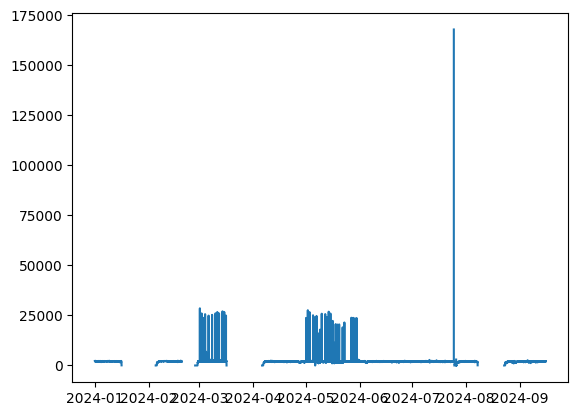

In [6]:
import matplotlib.pyplot as plt
plt.plot(df.index,df['前爐SOx濃度'])
plt.show()

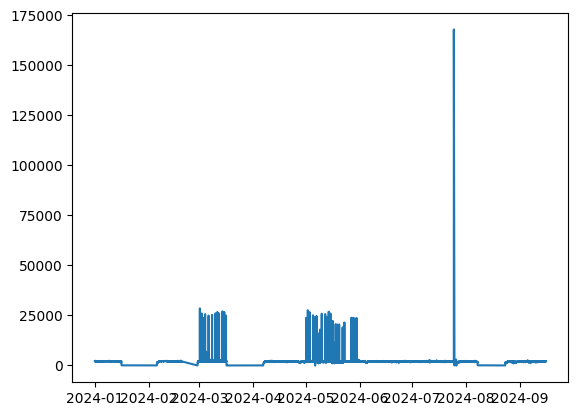

In [7]:
data = df[df['前爐SOx濃度']>0]
data = data[features+y_col]
plt.plot(data.index,data['前爐SOx濃度'])
plt.show()

# 馬氏距離刪除離群值

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import chi2

def del_outliers_mahalanobis(df):
  mean_vec = df.mean().values
  cov_matrix = np.cov(df.values, rowvar=False)
  inv_cov_matrix = np.linalg.inv(cov_matrix)

  # Step 2: 計算每筆資料的馬氏距離
  def mahalanobis(x, mean, inv_cov):
      diff = x - mean
      return np.sqrt(diff.T @ inv_cov @ diff)

  # 計算所有樣本的距離
  distances = df.apply(lambda row: mahalanobis(row.values, mean_vec, inv_cov_matrix), axis=1)

  # Step 3: 決定閾值，例如卡方分布下95%置信區間的臨界值（自由度=2因為是兩欄）
  threshold = np.sqrt(chi2.ppf(0.99, df=2))

  # Step 4: 過濾掉離群樣本
  df_clean = df[distances < threshold]

  # 如果你想看哪些是離群值
  outliers = df[distances >= threshold]

  return df_clean

In [9]:
data = data.dropna(axis=1)
data.shape

(47722, 24)

In [10]:
data.isnull().sum().sum()

np.int64(0)

In [11]:
features = list(set(features)&set(data.columns))
features

['MLUT4_TE-252D',
 'MLUT4_FT-951AB',
 'MLUT4_PDT-232',
 'MLUT4_TE-251I',
 'MLUT4_PIC-233',
 'MLUT4_FT-956',
 'MLUT4_PDT-231',
 'MLUT4_FT-792020',
 'MLUT4_IT-E7925A',
 '鈣硫比',
 'MLUT4_AIA792101A',
 'MLUT4_FT-232',
 'MLUT4_FQ-205',
 'DeSOx_1st',
 'MLUT4_FT-V004',
 'MLUT4_FIC-231C',
 'MLUT4_FT-957',
 'MLUT4_AT-237',
 'MLUT4_FIC-231B',
 'MLUT4_FIC-231A',
 'MLUT4_FIC-233',
 'MLUT4_AIA792101B',
 'MLUT4_ZT-231']

MLUT4_TE-252D


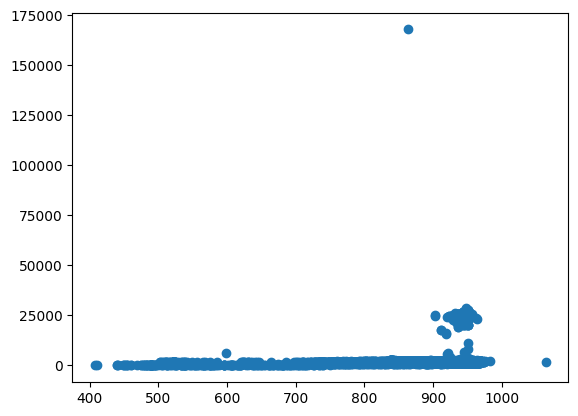

MLUT4_FT-951AB


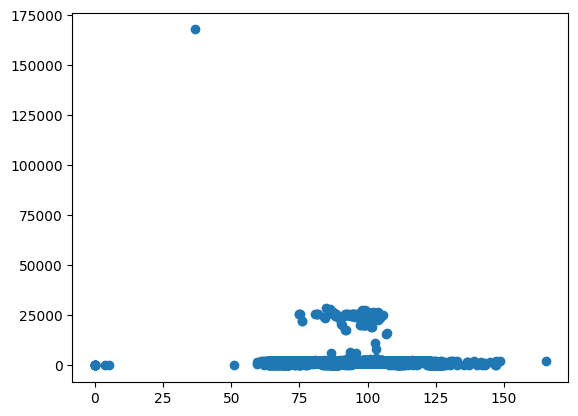

MLUT4_PDT-232


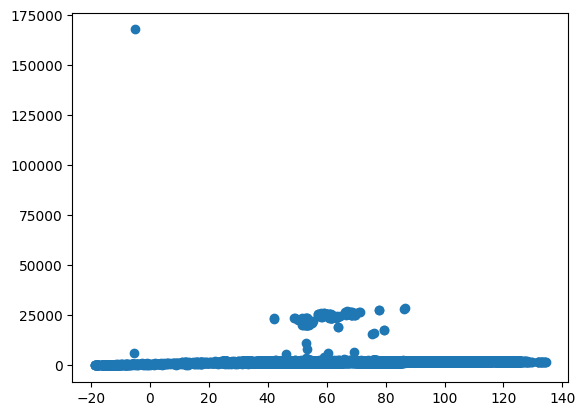

MLUT4_TE-251I


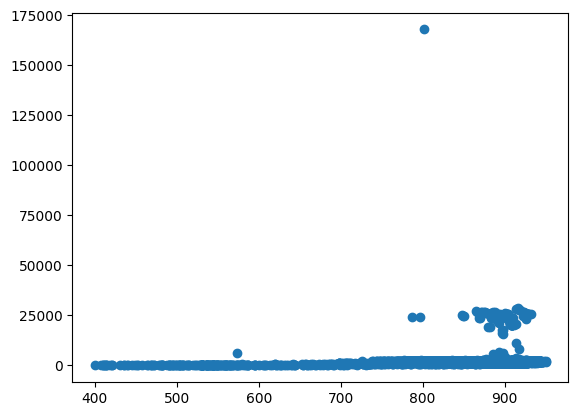

MLUT4_PIC-233


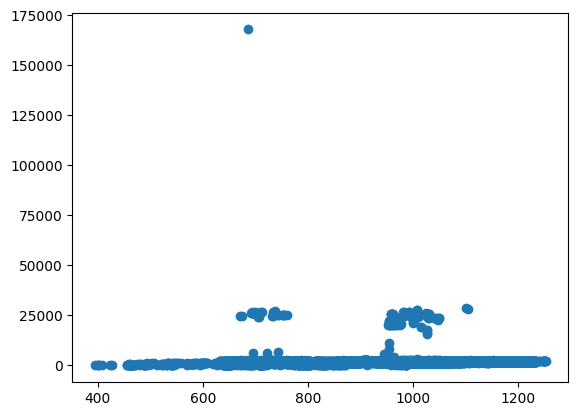

MLUT4_FT-956


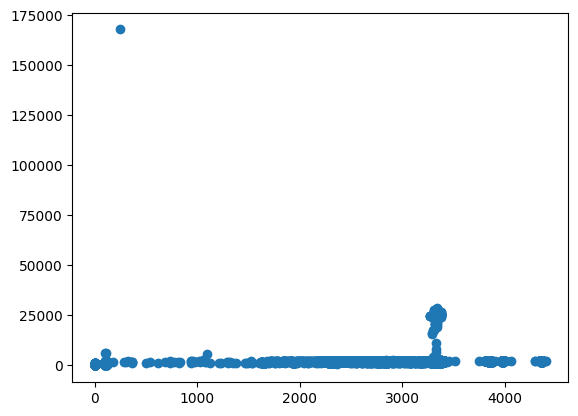

MLUT4_PDT-231


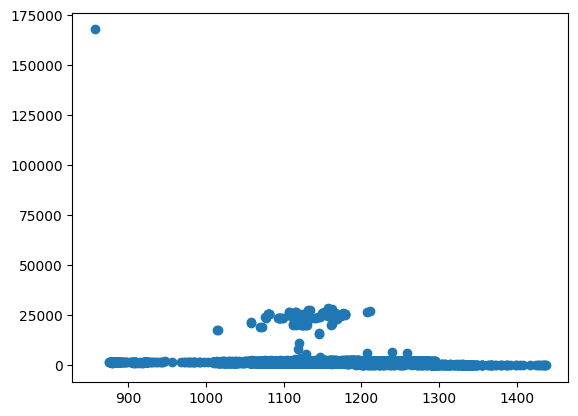

MLUT4_FT-792020


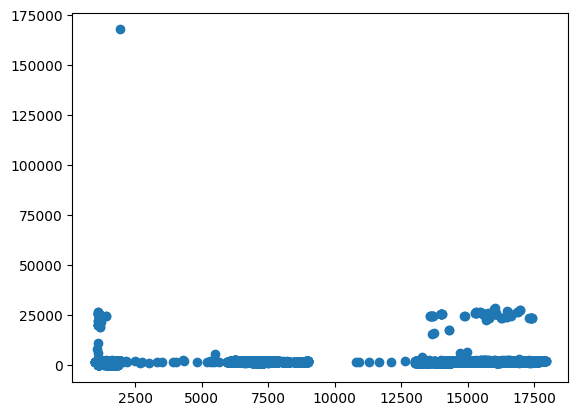

MLUT4_IT-E7925A


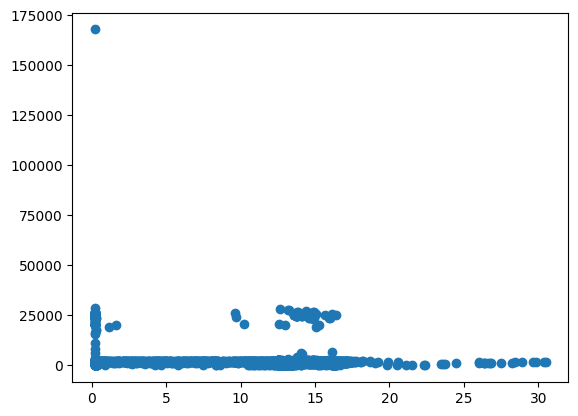

鈣硫比


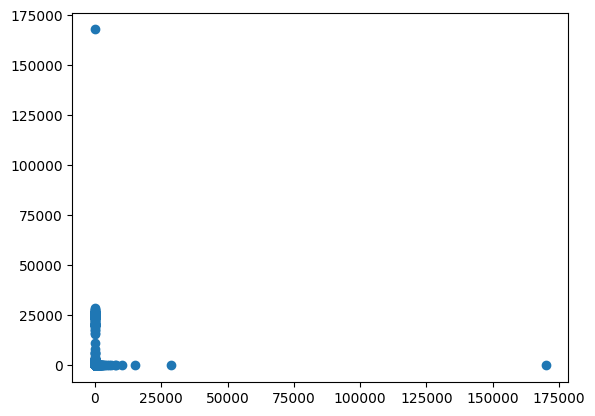

MLUT4_AIA792101A


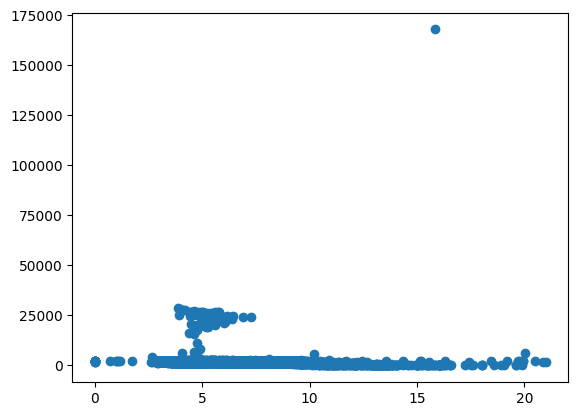

MLUT4_FT-232


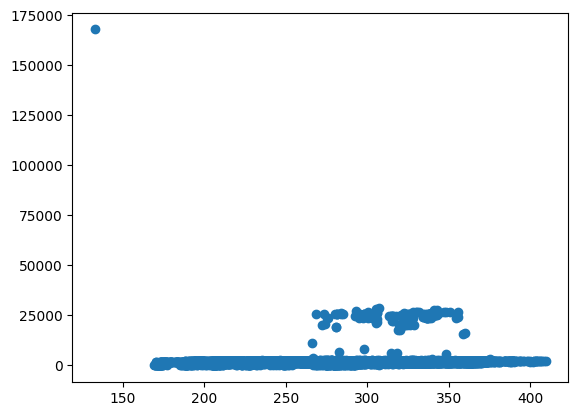

MLUT4_FQ-205


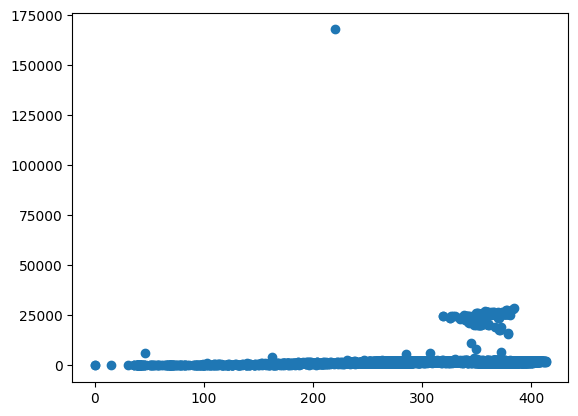

DeSOx_1st


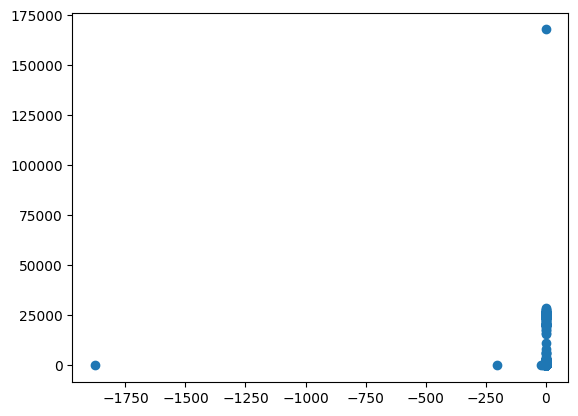

MLUT4_FT-V004


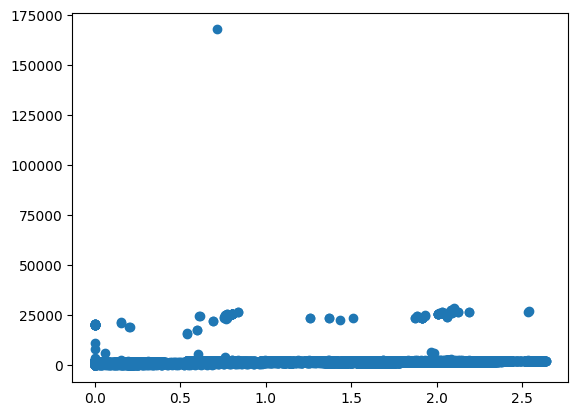

MLUT4_FIC-231C


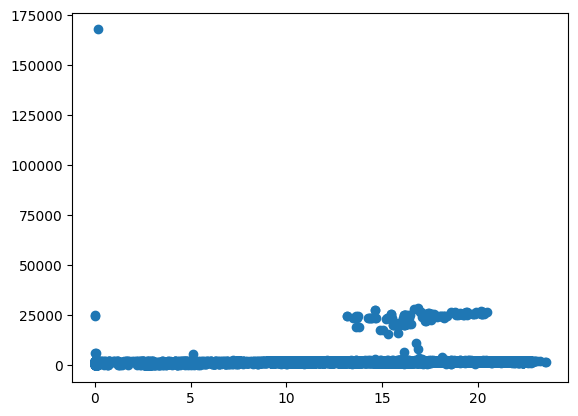

MLUT4_FT-957


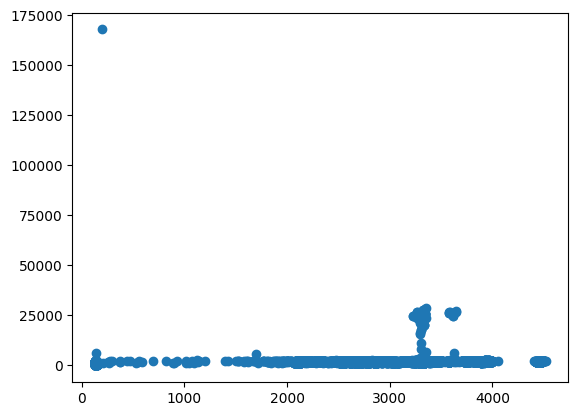

MLUT4_AT-237


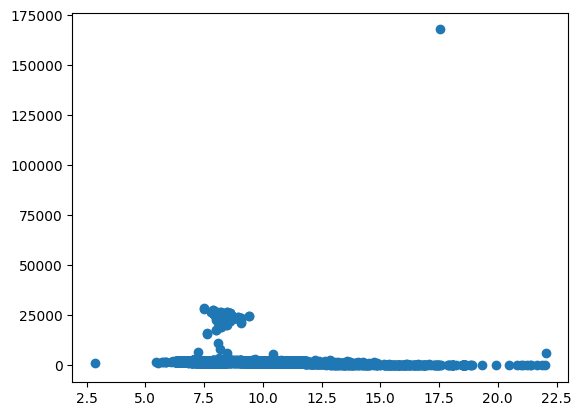

MLUT4_FIC-231B


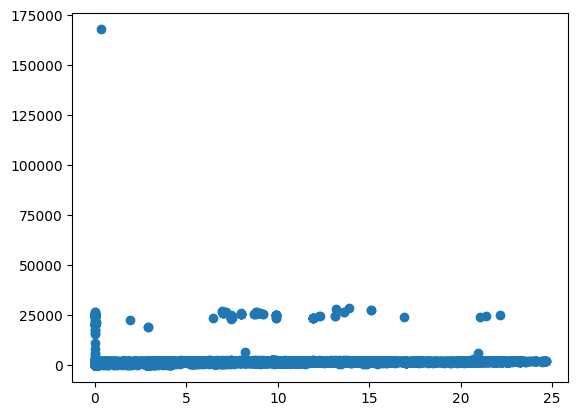

MLUT4_FIC-231A


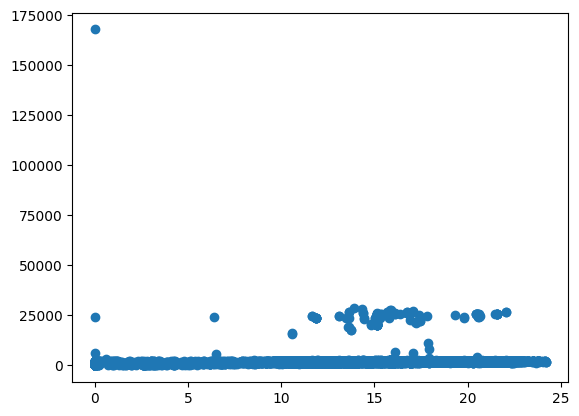

MLUT4_FIC-233


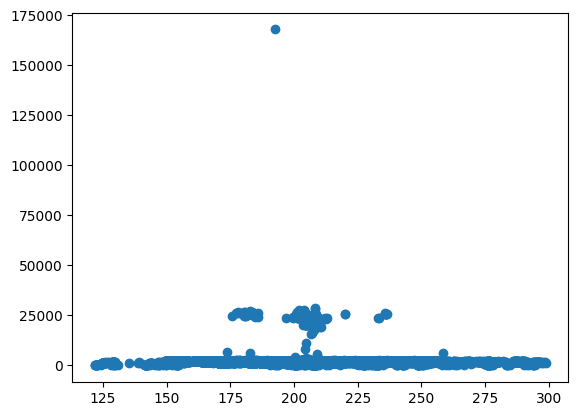

MLUT4_AIA792101B


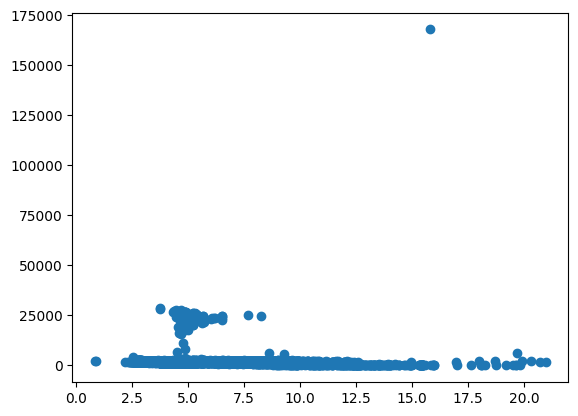

MLUT4_ZT-231


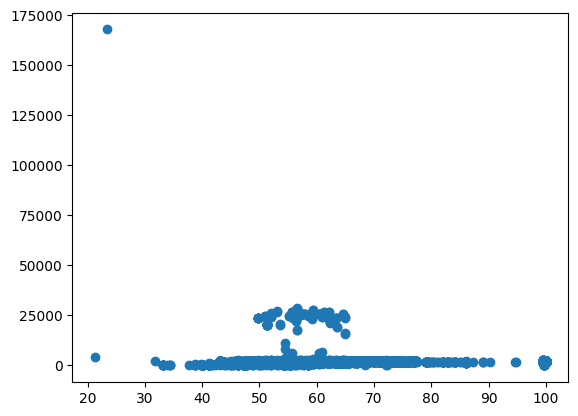

In [12]:
for i in features:
  plt.scatter(data[i],data['前爐SOx濃度'])
  print(i)
  plt.show()

In [13]:
#for i in features:
#  data = data.loc[del_outliers_mahalanobis(data[[i,'前爐SOx濃度']]).index,:]
#  plt.scatter(data[i],data['前爐SOx濃度'])
#  plt.show()

# 標準化

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data.loc[:,features] = scaler.fit_transform(data.loc[:,features])
data

,MLUT4_FT-956,MLUT4_FT-V004,MLUT4_FT-792020,MLUT4_FIC-231C,MLUT4_AT-237,MLUT4_FT-957,MLUT4_FIC-231B,MLUT4_FIC-231A,MLUT4_PIC-233,鈣硫比,...,MLUT4_FT-951AB,MLUT4_TE-251I,MLUT4_TE-252D,MLUT4_PDT-232,MLUT4_FIC-233,DeSOx_1st,MLUT4_ZT-231,MLUT4_IT-E7925A,MLUT4_PDT-231,前爐SOx濃度
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,1.533935,-2.671419,1.586622,1.099541,0.460914,1.182048,-1.811721,1.679867,-0.106153,-0.009827,...,0.262751,-0.063439,-1.530945,0.696920,-1.095342,0.007517,-0.300132,0.421193,1.240207,2230.093232
2024-01-01 00:05:00,1.526627,-2.671419,1.585459,1.097457,0.455568,1.181627,-1.811721,1.561660,-0.123011,-0.009830,...,0.351322,-0.058484,-1.561307,0.741896,-1.098324,0.007521,-0.300132,0.416225,1.174169,2220.527929
2024-01-01 00:10:00,1.519334,-2.671419,1.586520,1.095372,0.450221,1.175963,-1.811721,1.567112,-0.117985,-0.009834,...,0.340161,-0.055241,-1.615995,0.663919,-1.090123,0.007668,-0.300132,0.420648,1.206515,2237.129686
2024-01-01 00:15:00,1.520710,-2.671419,1.587125,1.134143,0.444404,1.199917,-1.811721,1.572564,-0.100905,-0.009838,...,0.329001,-0.123108,-1.607426,0.693230,-1.092261,0.007627,-0.300132,0.420648,1.200679,2227.895501
2024-01-01 00:20:00,1.522091,-2.671419,1.586951,1.064753,0.430660,1.176844,-1.811721,1.664022,-0.107974,-0.009842,...,0.367661,-0.048013,-1.585453,0.703571,-1.097100,0.007625,-0.300132,0.416124,1.176397,2211.052236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,-0.744619,0.447200,-0.147381,-0.279252,0.269512,-0.775481,0.543767,-0.492654,-0.259618,-0.007690,...,0.061160,0.079465,0.115447,-0.482931,0.805079,0.004653,2.351277,0.321782,0.359629,2082.274527
2024-09-15 23:40:00,-0.732990,0.447200,-0.150884,-0.284768,0.211160,-0.769115,0.545234,-0.492294,-0.240874,-0.007691,...,0.074779,0.057363,0.074901,-0.488685,0.796305,0.005040,2.351277,0.320841,0.366781,2071.948976
2024-09-15 23:45:00,-0.736379,0.447200,-0.149849,-0.279103,0.269036,-0.781092,0.548866,-0.491933,-0.220081,-0.007690,...,0.158388,0.031926,0.056302,-0.495355,0.809813,0.005197,2.351277,0.316179,0.416995,2088.339754


In [15]:
data.loc[:,features]

,MLUT4_TE-252D,MLUT4_FT-951AB,MLUT4_PDT-232,MLUT4_TE-251I,MLUT4_PIC-233,MLUT4_FT-956,MLUT4_PDT-231,MLUT4_FT-792020,MLUT4_IT-E7925A,鈣硫比,...,DeSOx_1st,MLUT4_FT-V004,MLUT4_FIC-231C,MLUT4_FT-957,MLUT4_AT-237,MLUT4_FIC-231B,MLUT4_FIC-231A,MLUT4_FIC-233,MLUT4_AIA792101B,MLUT4_ZT-231
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,-1.530945,0.262751,0.696920,-0.063439,-0.106153,1.533935,1.240207,1.586622,0.421193,-0.009827,...,0.007517,-2.671419,1.099541,1.182048,0.460914,-1.811721,1.679867,-1.095342,0.765963,-0.300132
2024-01-01 00:05:00,-1.561307,0.351322,0.741896,-0.058484,-0.123011,1.526627,1.174169,1.585459,0.416225,-0.009830,...,0.007521,-2.671419,1.097457,1.181627,0.455568,-1.811721,1.561660,-1.098324,0.765963,-0.300132
2024-01-01 00:10:00,-1.615995,0.340161,0.663919,-0.055241,-0.117985,1.519334,1.206515,1.586520,0.420648,-0.009834,...,0.007668,-2.671419,1.095372,1.175963,0.450221,-1.811721,1.567112,-1.090123,0.765963,-0.300132
2024-01-01 00:15:00,-1.607426,0.329001,0.693230,-0.123108,-0.100905,1.520710,1.200679,1.587125,0.420648,-0.009838,...,0.007627,-2.671419,1.134143,1.199917,0.444404,-1.811721,1.572564,-1.092261,0.767000,-0.300132
2024-01-01 00:20:00,-1.585453,0.367661,0.703571,-0.048013,-0.107974,1.522091,1.176397,1.586951,0.416124,-0.009842,...,0.007625,-2.671419,1.064753,1.176844,0.430660,-1.811721,1.664022,-1.097100,0.779389,-0.300132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,0.115447,0.061160,-0.482931,0.079465,-0.259618,-0.744619,0.359629,-0.147381,0.321782,-0.007690,...,0.004653,0.447200,-0.279252,-0.775481,0.269512,0.543767,-0.492654,0.805079,-0.349415,2.351277
2024-09-15 23:40:00,0.074901,0.074779,-0.488685,0.057363,-0.240874,-0.732990,0.366781,-0.150884,0.320841,-0.007691,...,0.005040,0.447200,-0.284768,-0.769115,0.211160,0.545234,-0.492294,0.796305,-0.331944,2.351277
2024-09-15 23:45:00,0.056302,0.158388,-0.495355,0.031926,-0.220081,-0.736379,0.416995,-0.149849,0.316179,-0.007690,...,0.005197,0.447200,-0.279103,-0.781092,0.269036,0.548866,-0.491933,0.809813,-0.291863,2.351277


# 線性回歸

In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

X,Y = data[features],data['前爐SOx濃度']

# 2. 資料切分：訓練 80% / 測試 20%
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練線性回歸模型
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 預測
y_pred = model.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_reg = res
res_reg

,R2,RMSE,MAPE
0,0.011325,2089.953453,110.067006


# Ridge 回歸

In [17]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 切分資料為訓練與測試集
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 Ridge 回歸模型
ridge = Ridge(alpha=1.0)  # 可嘗試不同的 alpha，例如 0.1, 1, 10
ridge.fit(X_train, y_train)

# 4. 預測
y_pred = ridge.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_ridge = res
res_ridge


,R2,RMSE,MAPE
0,0.011323,2089.955924,110.078288


# Lasso 回歸

In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立 Lasso 模型並訓練
lasso = Lasso(alpha=0.1)  # alpha 越大，壓縮越強，更多係數會變 0
lasso.fit(X_train, y_train)

# 4. 預測
y_pred = lasso.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_lasso = res
res_lasso


,R2,RMSE,MAPE
0,0.01126,2090.022353,110.472137


In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立 ElasticNet 模型並訓練
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5 表示 L1:L2 = 1:1
elastic_net.fit(X_train, y_train)

# 4. 預測
y_pred = elastic_net.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_ElasticNet = res
res_ElasticNet


,R2,RMSE,MAPE
0,0.009585,2091.791943,120.060822


In [20]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 訓練/測試資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 PLS 模型（選擇主成分數目）
pls = PLSRegression(n_components=2)
pls.fit(X_train, y_train)

# 4. 預測
y_pred = pls.predict(X_test).ravel()  # .ravel() 將輸出轉成一維陣列

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_PLS = res
res_PLS


,R2,RMSE,MAPE
0,0.00701,2094.508917,122.379129


In [21]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from tqdm import tqdm

# 2. 訓練/測試資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, warm_start=True, random_state=42)
rf.fit(X_train, y_train)

# 4. 預測
y_pred = rf.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_rf = res
res_rf


,R2,RMSE,MAPE
0,0.302996,1754.799534,1.937561


In [22]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 XGBoost 回歸模型
xgb = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

# 4. 預測
y_pred = xgb.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_xgb = res
res_xgb


,R2,RMSE,MAPE
0,0.289258,1772.008907,3.018643


In [23]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. 建立並訓練 SVR 模型
svr = SVR()
svr.fit(X_train,y_train)

# 5. 預測（記得反標準化）
y_pred = svr.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_svr = res
res_svr


,R2,RMSE,MAPE
0,0.003776,2097.917378,263.274356


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import numpy as np

# 切分資料
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 轉成Tensor
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# 2. 定義 MLP 模型
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=len(features))

# 3. 損失函數與優化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. 訓練迴圈
n_epochs = 300
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}")

# 5. 測試與評估
model.eval()
with torch.no_grad():
    y_pred_t = model(X_test_t).view(-1).numpy()

r2 = r2_score(y_test, y_pred_t)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_t))
mape = mean_absolute_percentage_error(y_test, y_pred_t)

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_mlp = res
res_mlp


Epoch [5/300], Loss: 5380183.5000
Epoch [10/300], Loss: 5354700.0000
Epoch [15/300], Loss: 5292142.0000
Epoch [20/300], Loss: 5166023.5000
Epoch [25/300], Loss: 4944030.0000
Epoch [30/300], Loss: 4595477.5000
Epoch [35/300], Loss: 4106655.5000
Epoch [40/300], Loss: 3507985.0000
Epoch [45/300], Loss: 2905883.0000
Epoch [50/300], Loss: 2472961.2500
Epoch [55/300], Loss: 2302192.0000
Epoch [60/300], Loss: 2235777.5000
Epoch [65/300], Loss: 2115300.7500
Epoch [70/300], Loss: 1991145.5000
Epoch [75/300], Loss: 1904242.7500
Epoch [80/300], Loss: 1828646.1250
Epoch [85/300], Loss: 1752696.0000
Epoch [90/300], Loss: 1685123.6250
Epoch [95/300], Loss: 1627866.1250
Epoch [100/300], Loss: 1577217.8750
Epoch [105/300], Loss: 1533006.1250
Epoch [110/300], Loss: 1495908.2500
Epoch [115/300], Loss: 1465221.1250
Epoch [120/300], Loss: 1440135.0000
Epoch [125/300], Loss: 1419648.6250
Epoch [130/300], Loss: 1402535.3750
Epoch [135/300], Loss: 1388146.3750
Epoch [140/300], Loss: 1375898.3750
Epoch [145/3

,R2,RMSE,MAPE
0,0.024349,2076.142197,0.385091


In [25]:
res = pd.concat([res_reg,res_ridge,res_lasso,res_ElasticNet,res_PLS,res_rf,res_xgb,res_svr,res_mlp])
res.index = ['reg','ridge','lasso','elastic','PLS','rf','xgb','svr','mlp']
res

,R2,RMSE,MAPE
reg,0.011325,2089.953453,110.067006
ridge,0.011323,2089.955924,110.078288
lasso,0.011260,2090.022353,110.472137
elastic,0.009585,2091.791943,120.060822
PLS,0.007010,2094.508917,122.379129
rf,0.302996,1754.799534,1.937561
xgb,0.289258,1772.008907,3.018643
svr,0.003776,2097.917378,263.274356
mlp,0.024349,2076.142197,0.385091


<ipython-input-26-3284107390>:12: UserWarning: Glyph 37411 (\N{CJK UNIFIED IDEOGRAPH-9223}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-26-3284107390>:12: UserWarning: Glyph 30827 (\N{CJK UNIFIED IDEOGRAPH-786B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
<ipython-input-26-3284107390>:12: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37411 (\N{CJK UNIFIED IDEOGRAPH-9223}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30827 (\N{CJK UNIFIED IDEOGRAPH-786B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font

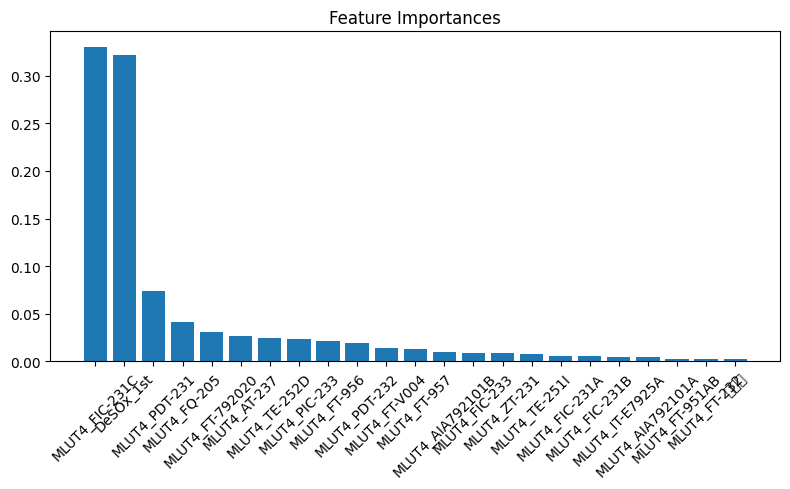

In [26]:
import matplotlib.pyplot as plt

# 排序特徵重要度
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 畫圖
plt.figure(figsize=(8, 5))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()
